In [1]:
from pymongo import MongoClient

client = MongoClient("mongodb://localhost:27017/")
db = client["upme_solar_db"]
print("Conexión exitosa:", client.server_info()["version"])
print("Colecciones:", db.list_collection_names())

Conexión exitosa: 8.3.2
Colecciones: []


In [4]:
import pandas as pd

# Verificar que los archivos se pueden leer
df_google = pd.read_csv(r"C:\Users\jtviv\OneDrive\Escritorio\procesados\google_pdet_filtrado.csv")
df_ms = pd.read_csv(r"C:\Users\jtviv\OneDrive\Escritorio\procesados\microsoft_pdet_limpio.csv")

print("Google:", len(df_google), "filas")
print("Microsoft:", len(df_ms), "filas")
print("\nColumnas Google:", df_google.columns.tolist())
print("Columnas Microsoft:", df_ms.columns.tolist())

Google: 2263446 filas
Microsoft: 5258 filas

Columnas Google: ['latitude', 'longitude', 'area_in_meters', 'confidence', 'geometry', 'full_plus_code', 'cod_dane_municipio']
Columnas Microsoft: ['geometry', 'area_m2', 'height', 'fuente']


In [6]:
import json
from datetime import datetime

# ── Microsoft ──────────────────────────────────────────
col_ms = db["ms_buildings"]
col_ms.drop()

batch = []
errores = 0
total = 0
BATCH_SIZE = 1000

for _, fila in df_ms.iterrows():
    try:
        geom_str = fila["geometry"]
        if isinstance(geom_str, str):
            geom_str = geom_str.replace('""', '"').strip('"')
        geom = json.loads(geom_str)
        doc = {
            "geometry":           geom,
            "area_m2":            float(fila["area_m2"]),
            "cod_dane_municipio": None,
            "fuente":             "microsoft",
            "cargado_en":         datetime.now()
        }
        batch.append(doc)
    except:
        errores += 1

if batch:
    col_ms.insert_many(batch)
    total = len(batch)

col_ms.create_index([("geometry", "2dsphere")])
col_ms.create_index([("cod_dane_municipio", 1)])
print(f"✅ ms_buildings: {col_ms.count_documents({}):,} documentos")
print(f"Errores: {errores}")

✅ ms_buildings: 5,258 documentos
Errores: 0


In [7]:
from shapely import wkt

col_goo = db["goo_buildings"]
col_goo.drop()

batch = []
errores = 0
total = 0
BATCH_SIZE = 10000

for _, fila in df_google.iterrows():
    try:
        geom = wkt.loads(fila["geometry"])
        doc = {
            "geometry":           geom.__geo_interface__,
            "area_m2":            float(fila["area_in_meters"]),
            "confidence":         float(fila["confidence"]),
            "cod_dane_municipio": str(fila["cod_dane_municipio"]),
            "fuente":             "google",
            "cargado_en":         datetime.now()
        }
        batch.append(doc)
    except:
        errores += 1
        continue

    if len(batch) >= BATCH_SIZE:
        col_goo.insert_many(batch)
        total += len(batch)
        batch = []
        print(f"Insertados: {total:,} | Errores: {errores}")

if batch:
    col_goo.insert_many(batch)
    total += len(batch)

col_goo.create_index([("geometry", "2dsphere")])
col_goo.create_index([("cod_dane_municipio", 1)])
col_goo.create_index([("confidence", -1)])
print(f"\n✅ goo_buildings: {col_goo.count_documents({}):,} documentos")
print(f"Errores: {errores}")

Insertados: 10,000 | Errores: 0
Insertados: 20,000 | Errores: 0
Insertados: 30,000 | Errores: 0
Insertados: 40,000 | Errores: 0
Insertados: 50,000 | Errores: 0
Insertados: 60,000 | Errores: 0
Insertados: 70,000 | Errores: 0
Insertados: 80,000 | Errores: 0
Insertados: 90,000 | Errores: 0
Insertados: 100,000 | Errores: 0
Insertados: 110,000 | Errores: 0
Insertados: 120,000 | Errores: 0
Insertados: 130,000 | Errores: 0
Insertados: 140,000 | Errores: 0
Insertados: 150,000 | Errores: 0
Insertados: 160,000 | Errores: 0
Insertados: 170,000 | Errores: 0
Insertados: 180,000 | Errores: 0
Insertados: 190,000 | Errores: 0
Insertados: 200,000 | Errores: 0
Insertados: 210,000 | Errores: 0
Insertados: 220,000 | Errores: 0
Insertados: 230,000 | Errores: 0
Insertados: 240,000 | Errores: 0
Insertados: 250,000 | Errores: 0
Insertados: 260,000 | Errores: 0
Insertados: 270,000 | Errores: 0
Insertados: 280,000 | Errores: 0
Insertados: 290,000 | Errores: 0
Insertados: 300,000 | Errores: 0
Insertados: 310,000

In [8]:
import geopandas as gpd
from datetime import datetime

# Cargar municipios
gdf_pdet = gpd.read_file(r"C:\Users\jtviv\OneDrive - Pontificia Universidad Javeriana\municipios_pdet.geojson")
print(f"Total municipios: {len(gdf_pdet)}")
print(f"Columnas: {gdf_pdet.columns.tolist()}")

# Cargar a MongoDB
col_mpio = db["municipios_pdet"]
col_mpio.drop()

docs = []
for _, fila in gdf_pdet.iterrows():
    doc = {
        "cod_dane":       str(fila["cod_dane"]),
        "nombre":         fila["Municipio"],
        "departamento":   fila["Departamento"],
        "subregion_pdet": fila["SubPDET"],
        "area_km2":       float(fila["area_km2"]),
        "pdet":           True,
        "geometry":       fila["geometry"].__geo_interface__,
        "fuente":         "MGN2025",
        "cargado_en":     datetime.now()
    }
    docs.append(doc)

col_mpio.insert_many(docs)
col_mpio.create_index([("geometry", "2dsphere")])
col_mpio.create_index([("cod_dane", 1)], unique=True)
print(f"✅ municipios_pdet: {col_mpio.count_documents({})} documentos")

Total municipios: 170
Columnas: ['dpto_ccdgo', 'mpio_ccdgo', 'mpio_cdpmp', 'dpto_cnmbr', 'mpio_cnmbr', 'mpio_crslc', 'mpio_tipo', 'mpio_narea', 'mpio_nano', 'shape_Leng', 'shape_Area', 'cod_dane', 'SubPDET', 'CodDept', 'Departamento', 'CodMuni', 'Municipio', 'area_km2', 'bbox', 'geometry']
✅ municipios_pdet: 170 documentos


In [9]:
print("Asignando municipios a Microsoft...")
actualizados = 0

for mpio in col_mpio.find({}, {"cod_dane": 1, "nombre": 1, "geometry": 1}):
    resultado = col_ms.update_many(
        {
            "cod_dane_municipio": None,
            "geometry": {
                "$geoIntersects": {
                    "$geometry": mpio["geometry"]
                }
            }
        },
        {"$set": {"cod_dane_municipio": mpio["cod_dane"]}}
    )
    if resultado.modified_count > 0:
        print(f"  {mpio['nombre']}: {resultado.modified_count} edificios")
        actualizados += resultado.modified_count

print(f"\n✅ Total actualizados: {actualizados} de {col_ms.count_documents({})} edificios")

Asignando municipios a Microsoft...
  SOLANO: 722 edificios
  LEGUÍZAMO: 4536 edificios

✅ Total actualizados: 5258 de 5258 edificios


In [11]:
# Verificar cuáles códigos no tienen nombre
for codigo in ["5837", "5045"]:
    mpio = col_mpio.find_one({"cod_dane": codigo})
    print(f"{codigo}: {mpio}")
    
    # Buscar con cero adelante
    mpio2 = col_mpio.find_one({"cod_dane": "0" + codigo})
    print(f"0{codigo}: {mpio2}")

5837: None
05837: {'_id': ObjectId('6a13d3afd93a0a697edc6a71'), 'cod_dane': '05837', 'nombre': 'TURBO', 'departamento': 'ANTIOQUIA', 'subregion_pdet': 'URABÁ ANTIOQUEÑO', 'area_km2': 2923.242082232779, 'pdet': True, 'geometry': {'type': 'Polygon', 'coordinates': [[[-76.40265167059567, 8.463466090318434], [-76.40281219517328, 8.463667484680798], [-76.40365554501386, 8.463604365405388], [-76.40385081375939, 8.463217219057185], [-76.40398280063437, 8.46192582692504], [-76.40482828667041, 8.460635668180771], [-76.40502292928971, 8.460057634174177], [-76.40502389228442, 8.460054774834362], [-76.40507663241681, 8.460041744760758], [-76.40511761898262, 8.460031618942821], [-76.40547938431058, 8.459942234704158], [-76.40580259301748, 8.459862377106731], [-76.40632262635324, 8.459217464372216], [-76.40638850166215, 8.458636348243374], [-76.40638917629747, 8.45824886323004], [-76.40664964212334, 8.45766808127479], [-76.40678049083192, 8.457022494803311], [-76.40652171294175, 8.456634560631926], 

In [12]:
# Corregir códigos de 4 dígitos en goo_buildings
problemas = col_goo.count_documents({
    "cod_dane_municipio": {"$regex": "^[0-9]{4}$"}
})
print(f"Documentos con código de 4 dígitos: {problemas:,}")

if problemas > 0:
    col_goo.update_many(
        {"cod_dane_municipio": {"$regex": "^[0-9]{4}$"}},
        [{"$set": {"cod_dane_municipio": {
            "$concat": ["0", "$cod_dane_municipio"]
        }}}]
    )
    print("✅ Códigos corregidos")

# Verificar
restantes = col_goo.count_documents({
    "cod_dane_municipio": {"$regex": "^[0-9]{4}$"}
})
print(f"Códigos de 4 dígitos restantes: {restantes}")

Documentos con código de 4 dígitos: 309,598
✅ Códigos corregidos
Códigos de 4 dígitos restantes: 0


In [13]:
import pandas as pd

# ── TOP 10 MICROSOFT ──────────────────────────────────
pipeline_ms = [
    {"$match": {"cod_dane_municipio": {"$ne": None}}},
    {"$group": {
        "_id": "$cod_dane_municipio",
        "total_edificios": {"$sum": 1},
        "area_total_m2":   {"$sum": "$area_m2"}
    }},
    {"$sort": {"area_total_m2": -1}},
    {"$limit": 10}
]

rows_ms = []
for r in col_ms.aggregate(pipeline_ms):
    mpio = col_mpio.find_one({"cod_dane": r["_id"]})
    rows_ms.append({
        "Municipio":       mpio["nombre"] if mpio else r["_id"],
        "Departamento":    mpio["departamento"] if mpio else "",
        "N° Edificios":    r["total_edificios"],
        "Área Total (m²)": round(r["area_total_m2"], 2)
    })

df_top10_ms = pd.DataFrame(rows_ms)
print("TOP 10 MICROSOFT:")
print(df_top10_ms.to_string(index=False))

# ── TOP 10 GOOGLE ──────────────────────────────────────
pipeline_goo = [
    {"$match": {"cod_dane_municipio": {"$ne": None}}},
    {"$group": {
        "_id": "$cod_dane_municipio",
        "total_edificios": {"$sum": 1},
        "area_total_m2":   {"$sum": "$area_m2"}
    }},
    {"$sort": {"area_total_m2": -1}},
    {"$limit": 10}
]

rows_goo = []
for r in col_goo.aggregate(pipeline_goo):
    mpio = col_mpio.find_one({"cod_dane": r["_id"]})
    rows_goo.append({
        "Municipio":       mpio["nombre"] if mpio else r["_id"],
        "Departamento":    mpio["departamento"] if mpio else "",
        "N° Edificios":    r["total_edificios"],
        "Área Total (m²)": round(r["area_total_m2"], 2)
    })

df_top10_goo = pd.DataFrame(rows_goo)
print("\nTOP 10 GOOGLE:")
print(df_top10_goo.to_string(index=False))

TOP 10 MICROSOFT:
Municipio Departamento  N° Edificios  Área Total (m²)
LEGUÍZAMO     PUTUMAYO          4536         645665.1
   SOLANO      CAQUETÁ           722          56480.8

TOP 10 GOOGLE:
             Municipio    Departamento  N° Edificios  Área Total (m²)
           SANTA MARTA       MAGDALENA        154601      15042266.01
            VALLEDUPAR           CESAR        141586      14440557.18
          BUENAVENTURA VALLE DEL CAUCA         88341       7104404.67
             FLORENCIA         CAQUETÁ         48674       6925916.84
                 TURBO       ANTIOQUIA         66587       5607169.70
               CIÉNAGA       MAGDALENA         34439       3660305.00
SANTANDER DE QUILICHAO           CAUCA         30564       3588799.88
  SAN ANDRES DE TUMACO          NARIÑO         42556       3458019.47
              APARTADÓ       ANTIOQUIA         30278       3343477.98
                  TAME          ARAUCA         30013       3000073.12


In [14]:
import os
os.makedirs("outputs", exist_ok=True)

df_top10_ms.to_csv("outputs/top10_microsoft.csv", index=False)
df_top10_goo.to_csv("outputs/top10_google.csv", index=False)
print("✅ Tablas guardadas en outputs/")

✅ Tablas guardadas en outputs/


In [15]:
# Estadísticas generales de cada dataset
stats_ms = list(col_ms.aggregate([{"$group": {
    "_id": None,
    "total": {"$sum": 1},
    "area_total": {"$sum": "$area_m2"},
    "area_promedio": {"$avg": "$area_m2"},
    "area_max": {"$max": "$area_m2"},
    "area_min": {"$min": "$area_m2"}
}}]))[0]

stats_goo = list(col_goo.aggregate([{"$group": {
    "_id": None,
    "total": {"$sum": 1},
    "area_total": {"$sum": "$area_m2"},
    "area_promedio": {"$avg": "$area_m2"},
    "area_max": {"$max": "$area_m2"},
    "area_min": {"$min": "$area_m2"}
}}]))[0]

tabla_comparativa = pd.DataFrame([
    {"Aspecto": "Total edificaciones", "Microsoft": f"{stats_ms['total']:,}", "Google": f"{stats_goo['total']:,}"},
    {"Aspecto": "Área total (m²)", "Microsoft": f"{stats_ms['area_total']:,.0f}", "Google": f"{stats_goo['area_total']:,.0f}"},
    {"Aspecto": "Área promedio (m²)", "Microsoft": f"{stats_ms['area_promedio']:.1f}", "Google": f"{stats_goo['area_promedio']:.1f}"},
    {"Aspecto": "Área máxima (m²)", "Microsoft": f"{stats_ms['area_max']:.1f}", "Google": f"{stats_goo['area_max']:.1f}"},
    {"Aspecto": "Área mínima (m²)", "Microsoft": f"{stats_ms['area_min']:.1f}", "Google": f"{stats_goo['area_min']:.1f}"},
    {"Aspecto": "Año de imágenes", "Microsoft": "2014–2021", "Google": "2023"},
    {"Aspecto": "Licencia", "Microsoft": "ODbL", "Google": "CC BY-4.0 / ODbL"},
    {"Aspecto": "Municipios PDET cubiertos", "Microsoft": "2", "Google": "170"},
])

print(tabla_comparativa.to_string(index=False))
tabla_comparativa.to_csv("outputs/comparativa_datasets.csv", index=False)
print("\n✅ Guardada en outputs/comparativa_datasets.csv")

                  Aspecto Microsoft           Google
      Total edificaciones     5,258        2,263,446
          Área total (m²)   702,146      207,447,099
       Área promedio (m²)     133.5             91.7
         Área máxima (m²)    3754.7          20916.7
         Área mínima (m²)      11.4              2.5
          Año de imágenes 2014–2021             2023
                 Licencia      ODbL CC BY-4.0 / ODbL
Municipios PDET cubiertos         2              170

✅ Guardada en outputs/comparativa_datasets.csv


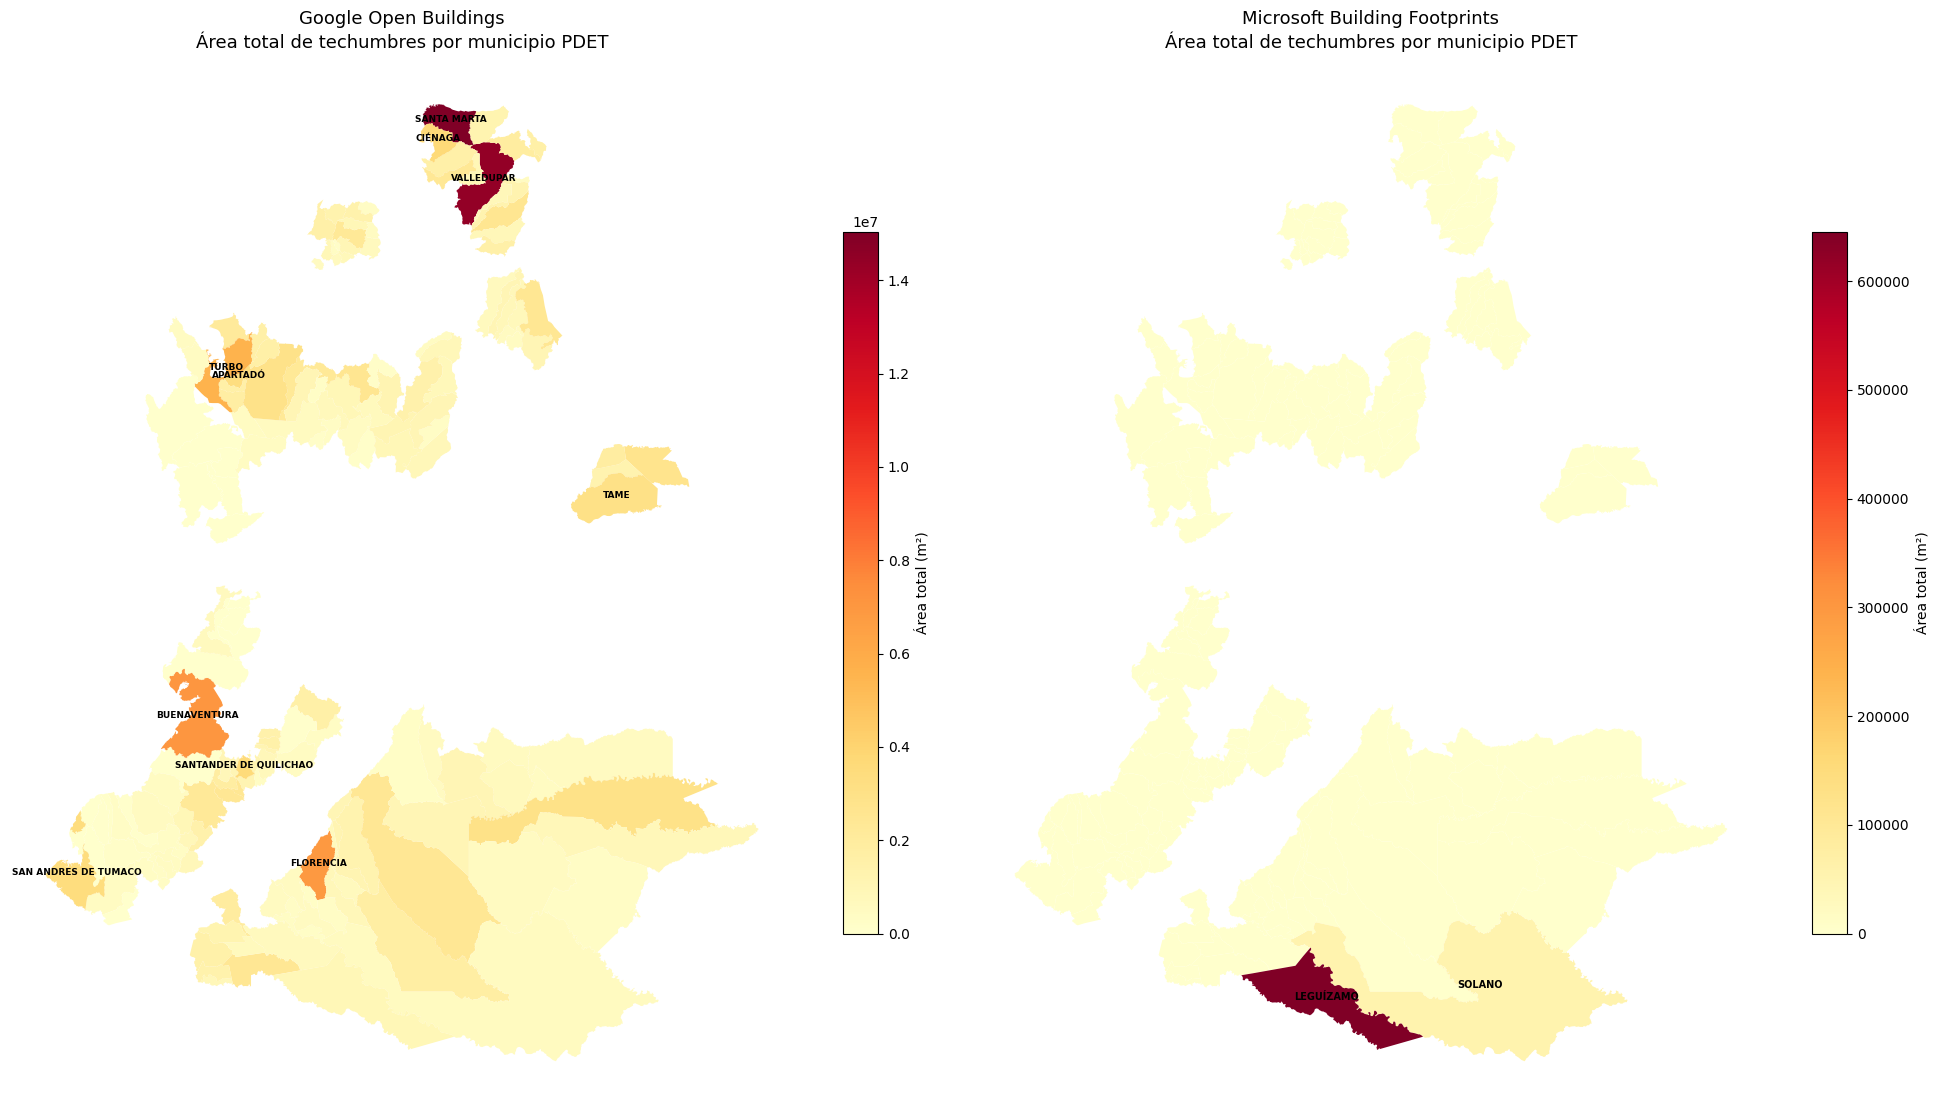

✅ Mapa guardado en outputs/mapa_coropletico.png


In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(20, 12))

# ── GOOGLE ──────────────────────────────────────────────
gdf_pdet.plot(column="area_google", ax=axes[0], legend=True,
              cmap="YlOrRd", missing_kwds={"color": "lightgrey"},
              legend_kwds={"label": "Área total (m²)", "shrink": 0.6})
axes[0].set_title("Google Open Buildings\nÁrea total de techumbres por municipio PDET", fontsize=13)
axes[0].axis("off")

# Etiquetas Top 10 Google
top10_codigos_goo = [r["_id"] for r in col_goo.aggregate([
    {"$match": {"cod_dane_municipio": {"$ne": None}}},
    {"$group": {"_id": "$cod_dane_municipio", "area": {"$sum": "$area_m2"}}},
    {"$sort": {"area": -1}},
    {"$limit": 10}
])]

for _, row in gdf_pdet[gdf_pdet["cod_dane"].isin(top10_codigos_goo)].iterrows():
    centroid = row.geometry.centroid
    axes[0].annotate(row["Municipio"], xy=(centroid.x, centroid.y),
                     fontsize=6.5, ha="center", color="black",
                     fontweight="bold")

# ── MICROSOFT ────────────────────────────────────────────
gdf_pdet.plot(column="area_ms", ax=axes[1], legend=True,
              cmap="YlOrRd", missing_kwds={"color": "lightgrey"},
              legend_kwds={"label": "Área total (m²)", "shrink": 0.6})
axes[1].set_title("Microsoft Building Footprints\nÁrea total de techumbres por municipio PDET", fontsize=13)
axes[1].axis("off")

# Etiquetas Microsoft (solo los 2 que tienen datos)
for _, row in gdf_pdet[gdf_pdet["cod_dane"].isin(datos_ms.keys())].iterrows():
    centroid = row.geometry.centroid
    axes[1].annotate(row["Municipio"], xy=(centroid.x, centroid.y),
                     fontsize=7, ha="center", color="black",
                     fontweight="bold")

plt.tight_layout()
plt.savefig("outputs/mapa_coropletico.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Mapa guardado en outputs/mapa_coropletico.png")